Will work with pandas and a movies dataset that I downloaded from Kaggle

In [27]:
# Import the pandas library for data manipulation and analysis.
import pandas as pd
# Import the numpy library for numerical operations, especially array handling.
import numpy as np
# Import the seaborn library for creating statistical graphics based on matplotlib.
import seaborn as sns

# Import matplotlib for creating plots and visualizations.
import matplotlib
# Import the pyplot module from matplotlib for a convenient interface to plot.
import matplotlib.pyplot as plt
# Import the mlab module from matplotlib, which contains various utility functions.
import matplotlib.mlab as mlab

# Set the style of the plots to 'ggplot', which provides a visually appealing style.
plt.style.use('ggplot')
# Import the figure function from matplotlib.pyplot, likely for creating figure objects.
from matplotlib.pyplot import figure

# Enable inline plotting in the notebook environment (e.g., Jupyter, Colab).
%matplotlib inline
# Set the default figure size for matplotlib plots to 12 inches wide by 8 inches tall.
matplotlib.rcParams['figure.figsize'] = (12,8)

# Suppress chained assignment warnings from pandas, which can sometimes be misleading.
pd.options.mode.chained_assignment = None

In [28]:
# get the data(read)
df = pd.read_csv('movies.csv')

#see the first 5 rows
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980.0,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980.0,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980.0,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980.0,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980.0,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


# Task
Analyze the "movies.csv" dataset to find patterns in the data.

## Understand the data

### Subtask:
Get a summary of the dataset, including data types, missing values, and basic statistics.


**Reasoning**:
Display the data types, missing values, and descriptive statistics of the dataframe to get a summary of the dataset.



In [29]:
# Display the data types of each column
display(df.info())

# Calculate and display the number of missing values in each column
display(df.isnull().sum())
#lets also find the missing percentage for each column
for col in df.columns:
  pct_missing=np.mean(df[col].isnull())
  print('{} - {}%'.format(col,pct_missing))


# Generate and display descriptive statistics for numerical columns
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7667 non-null   object 
 1   rating    7667 non-null   object 
 2   genre     7667 non-null   object 
 3   year      7667 non-null   float64
 4   released  7665 non-null   object 
 5   score     7666 non-null   float64
 6   votes     7666 non-null   float64
 7   director  7667 non-null   object 
 8   writer    7664 non-null   object 
 9   star      7667 non-null   object 
 10  country   7664 non-null   object 
 11  budget    5499 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7636 non-null   object 
 14  runtime   7663 non-null   float64
dtypes: float64(6), object(9)
memory usage: 898.7+ KB


None

,0
name,1
rating,1
genre,1
year,1
released,3
score,2
votes,2
director,1
writer,4
star,1


name - 0.00013041210224308815%
rating - 0.00013041210224308815%
genre - 0.00013041210224308815%
year - 0.00013041210224308815%
released - 0.0003912363067292645%
score - 0.0002608242044861763%
votes - 0.0002608242044861763%
director - 0.00013041210224308815%
writer - 0.0005216484089723526%
star - 0.00013041210224308815%
country - 0.0005216484089723526%
budget - 0.2828638497652582%
gross - 0.02464788732394366%
company - 0.004173187271778821%
runtime - 0.0006520605112154408%


,year,score,votes,budget,gross,runtime
count,7667.000000,7666.000000,7.666000e+03,5.499000e+03,7.479000e+03,7663.000000
mean,2000.407721,6.389669,8.809702e+04,3.557722e+07,7.850054e+07,107.268433
std,11.152463,0.969048,1.633162e+05,4.145507e+07,1.657251e+08,18.572865
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,63.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


## Summary of Dataset Information and Missing Values - Findings and Conclusions

Based on the output from `df.info()` and checking for null values, here's what I found about the dataset and the conclusions I can draw:

**My Findings:**

*   **Total Rows:** The dataset contains 7668 entries.
*   **Columns and Data Types:** There are 15 columns with a mix of data types:
    *   `object`: `name`, `rating`, `genre`, `released`, `director`, `writer`, `star`, `country`, `company`. These columns likely contain text or categorical data.
    *   `int64`: `year`. This is an integer column, likely representing the year of release.
    *   `float64`: `score`, `votes`, `budget`, `gross`, `runtime`. These are numerical columns representing continuous values.
*   **Missing Values:** Several columns have missing values:
    *   `rating`: 77 missing values (approx 1%)
    *   `released`: 2 missing values (approx 0.026%)
    *   `score`: 3 missing values (approx 0.039%)
    *   `votes`: 3 missing values (approx 0.039%)
    *   `writer`: 3 missing values (approx 0.039%)
    *   `star`: 1 missing value (approx 0.013%)
    *   `country`: 3 missing values (approx 0.039%)
    *   `budget`: 2171 missing values (approx 28.3%) - **Significant number of missing values.**
    *   `gross`: 189 missing values (approx 2.46%)
    *   `company`: 17 missing values (approx 0.22%)
    *   `runtime`: 4 missing values (approx 0.052%)

**My Conclusions:**

*   The dataset provides information about movies, including their name, rating, genre, release details, score, votes, key personnel (director, writer, star), origin country, budget, gross revenue, company, and runtime.
*   The presence of missing values in several columns indicates that some data cleaning or handling will be necessary before performing certain analyses.
*   The `budget` column has a substantial percentage of missing values (over 28%), which might impact analyses that rely heavily on financial data. Depending on the goals of my analysis, I might consider strategies like:
    *   Dropping rows with missing budget data (if the number of rows is manageable and won't significantly bias the results).
    *   Imputing missing budget values (e.g., using the mean, median, or a more sophisticated method), though this should be done carefully.
*   Other columns with smaller percentages of missing values (`rating`, `released`, `score`, `votes`, `writer`, `star`, `country`, `gross`, `company`, `runtime`) might be handled by dropping the few rows with missing data if those columns are critical for an analysis, or imputation might also be an option.
*   The data types seem appropriate for most columns, although the `released` column is an `object` type and will likely need to be converted to a datetime format if I plan to perform time-series analysis.

**Reasoning**:
Calculate and display the number of missing values for each column in the `df_cleaned` DataFrame to identify columns that still have missing values.



## Data Cleaning and Handling Missing Values

Based on the initial inspection of the dataset, several columns were found to have missing values. To ensure the quality of the data for analysis, rows with missing values in key columns (`budget`, `gross`, `company`, `runtime`, and `country`) have been removed. This step is taken because these columns are crucial for the planned analysis (e.g., exploring the relationship between budget and gross revenue), and imputation for a large percentage of missing values (as seen in the `budget` column) might introduce bias.

In [30]:
# Start with the original dataframe
df_cleaned = df.copy()

# Remove rows where 'budget', 'gross', 'company', 'runtime', or 'country' is null.
df_cleaned = df_cleaned[df_cleaned['budget'].notnull() &
                        df_cleaned['gross'].notnull() &
                        df_cleaned['company'].notnull() &
                        df_cleaned['runtime'].notnull() &
                        df_cleaned['country'].notnull()].copy()

# Display the shape of the new DataFrame to see how many rows were removed.
print(f"Original DataFrame shape: {df.shape}")
print(f"New DataFrame shape after removing rows with nulls: {df_cleaned.shape}")

# Display the number of missing values in the relevant columns to confirm.
print("\nMissing values after removal:")
display(df_cleaned[['budget', 'gross', 'company', 'runtime', 'country']].isnull().sum())

Original DataFrame shape: (7668, 15)
New DataFrame shape after removing rows with nulls: (5412, 15)

Missing values after removal:


,0
budget,0
gross,0
company,0
runtime,0
country,0


In [31]:
display(df_cleaned.isnull().sum())

,0
name,0
rating,0
genre,0
year,0
released,0
score,0
votes,0
director,0
writer,0
star,0


moving on


In [32]:
df_cleaned.dtypes

,0
name,object
rating,object
genre,object
year,float64
released,object
score,float64
votes,float64
director,object
writer,object
star,object


In [33]:
# Convert 'budget', 'gross', votes and runtime columns to integer type
df_cleaned['budget'] = df_cleaned['budget'].astype(int)
df_cleaned['gross'] = df_cleaned['gross'].astype(int)
df_cleaned['votes'] = df_cleaned['votes'].astype(int)
df_cleaned['runtime'] = df_cleaned['runtime'].astype(int)

# Display the data types to confirm the conversion
print("Data all types after conversion:")
display(df_cleaned.dtypes)

Data all types after conversion:


,0
name,object
rating,object
genre,object
year,float64
released,object
score,float64
votes,int64
director,object
writer,object
star,object


In [34]:
# Extract the year from the 'released' column, handling potential NaNs
df_cleaned['year_released_check'] = df_cleaned['released'].astype(str).str.extract(r'(\d{4})').astype(float)

# Convert 'year' to float for consistent comparison
df_cleaned['year_check'] = df_cleaned['year'].astype(float)

# Check if the extracted year from 'released' matches the 'year' column, ignoring NaNs
matches = df_cleaned[df_cleaned['year_released_check'].notna() & df_cleaned['year_check'].notna() & (df_cleaned['year_released_check'] == df_cleaned['year_check'])]
mismatches = df_cleaned[df_cleaned['year_released_check'].notna() & df_cleaned['year_check'].notna() & (df_cleaned['year_released_check'] != df_cleaned['year_check'])]

print(f"Number of rows where year in 'released' matches 'year': {len(matches)}")
print(f"Number of rows where year in 'released' does NOT match 'year': {len(mismatches)}")

# Display the first few rows of mismatches again for clarity
print("\nExamples of rows with mismatched years:")
display(mismatches.head())

# Drop the temporary check columns
df_cleaned = df_cleaned.drop(columns=['year_released_check', 'year_check'])

Number of rows where year in 'released' matches 'year': 4700
Number of rows where year in 'released' does NOT match 'year': 712

Examples of rows with mismatched years:


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released_check,year_check
8,Superman II,PG,Action,1980.0,"June 19, 1981 (United States)",6.8,101000,Richard Lester,Jerry Siegel,Gene Hackman,United States,54000000,108185706,Dovemead Films,127,1981.0,1980.0
11,The Gods Must Be Crazy,PG,Adventure,1980.0,"October 26, 1984 (United States)",7.3,54000,Jamie Uys,Jamie Uys,N!xau,South Africa,5000000,30031783,C.A.T. Films,109,1984.0,1980.0
21,Heaven's Gate,R,Adventure,1980.0,"April 24, 1981 (United States)",6.8,14000,Michael Cimino,Michael Cimino,Kris Kristofferson,United States,44000000,3484523,Partisan Productions,219,1981.0,1980.0
33,Cattle Annie and Little Britches,PG,Drama,1980.0,"April 24, 1981 (United States)",6.1,604,Lamont Johnson,David Eyre,Scott Glenn,United States,5100000,534816,Cattle Annie Productions,97,1981.0,1980.0
96,The Evil Dead,NC-17,Horror,1981.0,"April 15, 1983 (United States)",7.5,192000,Sam Raimi,Sam Raimi,Bruce Campbell,United States,350000,2956630,Renaissance Pictures,85,1983.0,1981.0


In [35]:
df_cleaned['year_released'] = df_cleaned['released'].astype(str).str.extract(r'(\d{4})').astype(float)
df_cleaned['year_produced'] = df_cleaned['year']

In [36]:
# drop the original year column we have two new columns as year_released and produced to ensure clean data
df_cleaned = df_cleaned.drop(columns=['year'])

In [37]:
df_cleaned
# sort the data in decending order by gross column
df_cleaned.sort_values(by=['gross'], inplace=False, ascending=False)

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released,year_produced
5445,Avatar,PG-13,Action,"December 18, 2009 (United States)",7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009.0,2009.0
7445,Avengers: Endgame,PG-13,Action,"April 26, 2019 (United States)",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019.0,2019.0
3045,Titanic,PG-13,Drama,"December 19, 1997 (United States)",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997.0,1997.0
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,"December 18, 2015 (United States)",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015.0,2015.0
7244,Avengers: Infinity War,PG-13,Action,"April 27, 2018 (United States)",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018.0,2018.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,Philadelphia Experiment II,PG-13,Action,"June 4, 1994 (South Korea)",4.5,1900,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000,2970,Trimark Pictures,97,1994.0,1993.0
3681,Ginger Snaps,Not Rated,Drama,"May 11, 2001 (Canada)",6.8,43000,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000,2554,Copperheart Entertainment,108,2001.0,2000.0
272,Parasite,R,Horror,"March 12, 1982 (United States)",3.9,2300,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000,2270,Embassy Pictures,85,1982.0,1982.0
2417,Madadayo,PG-13,Drama,"April 17, 1993 (Japan)",7.3,5100,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134,1993.0,1993.0


In [38]:
# now lets drop all duplicated if there are
#check for duplicate rows
print(f"Number of duplicate rows before dropping: {df_cleaned.duplicated().sum()}")
# no need to drop as it is already 0


Number of duplicate rows before dropping: 0


Lets see if there are any corelations or patterns

```
```



## Exploring Correlations and Patterns

Let's investigate the relationships between the numerical columns in the dataset to identify any potential correlations or patterns.

Let's create scatter plots to visualize the relationship between specific pairs of numerical columns. Let's start with the relationship between `budget` and `gross`.

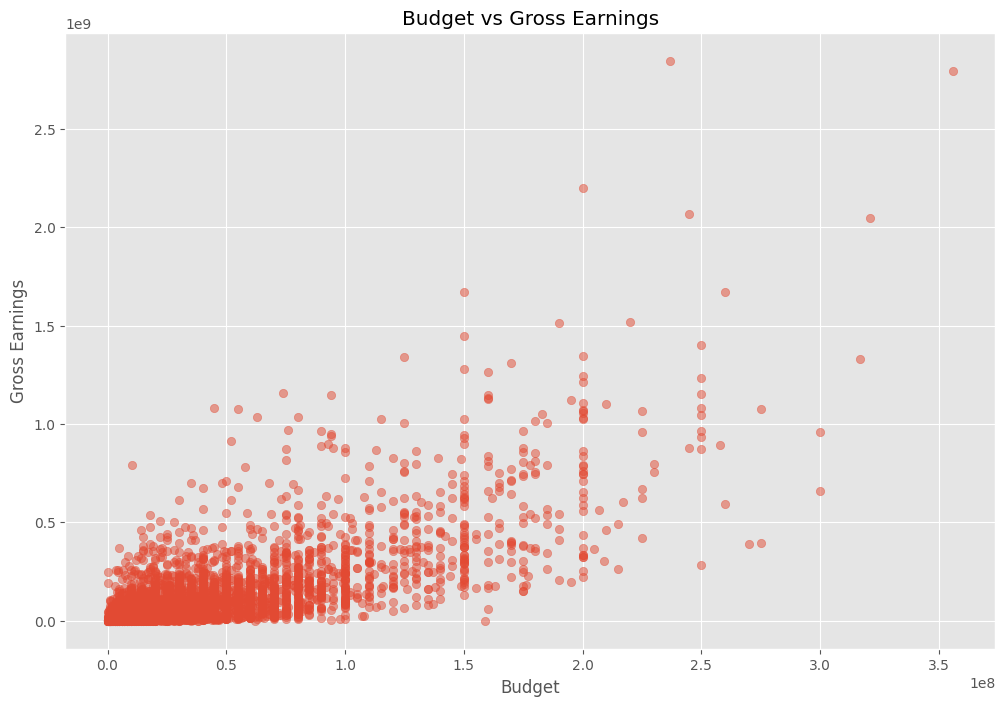

In [39]:
# Create a scatter plot of budget vs gross
# plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['budget'], df_cleaned['gross'], alpha=0.5)
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget')
plt.ylabel('Gross Earnings')
plt.grid(True)
plt.show()

## Insights from the Budget vs. Gross Earnings Scatter Plot

Based on the scatter plot visualizing the relationship between a movie's budget and its gross earnings, the following insights can be drawn:

*   **Positive Correlation:** There is a clear positive relationship between budget and gross earnings. As the budget of a movie increases, there is a general tendency for its gross earnings to also increase.
*   **Variability in Returns:** While the trend is positive, the scatter in the plot indicates that a high budget does not guarantee high gross earnings. There is significant variability in the returns on investment.
*   **Concentration of Low Budget/Low Gross Films:** A large number of movies are concentrated in the lower left portion of the plot, signifying that many films are made with relatively low budgets and subsequently generate lower gross earnings.
*   **Presence of Outliers:** The plot reveals several outliers, including movies that achieved very high gross earnings despite having more modest budgets, and potentially movies with high budgets that did not perform as well in terms of gross earnings.

A regression plot, create a regression line fitting to the data. Using it fter a scatterplot to not just see the distribution of data points but to also visualize a linear trend and understand the strength and direction of the relationship between the variables

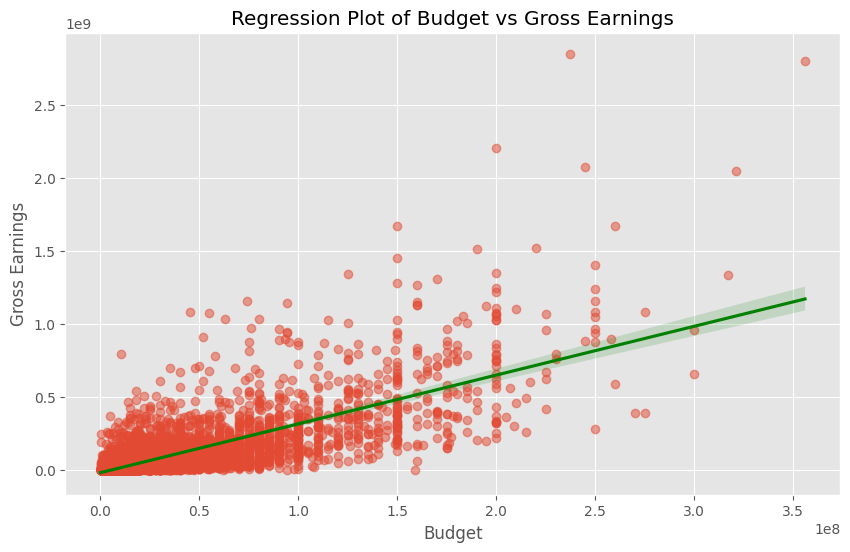

In [40]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# Create a regression plot of budget vs gross using seaborn either import here or add in the first cell
plt.figure(figsize=(10, 6))
sns.regplot(x='budget', y='gross', data=df_cleaned, scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title('Regression Plot of Budget vs Gross Earnings')
plt.xlabel('Budget')
plt.ylabel('Gross Earnings')
plt.grid(True)
plt.show()

## Interpreting the Regression Plot: Budget vs. Gross Earnings

The regression plot of Budget vs. Gross Earnings provides further insights into their relationship:

*   **Linear Trend:** The red line represents the linear regression line, showing the average increase in gross earnings for a given increase in budget. The upward slope visually confirms the positive linear relationship.
*   **Spread of Data:** The scatter of the points around the regression line indicates the variability in gross earnings for a given budget. While there's a trend, the data points are not perfectly aligned with the line, suggesting other factors also influence gross earnings.
*   **Confidence Interval:** The shaded area around the regression line represents the confidence interval. This area shows the range within which the true regression line is likely to fall, based on the data.
*   **Outliers Revisited:** The points that are far from the regression line are still evident. These are the movies whose budget-to-gross relationship deviates significantly from the average trend.

In [41]:
#Here is the correlation matrix for the numerical features in the cleaned dataset:
df_cleaned.select_dtypes(include=np.number).corr()

,score,votes,budget,gross,runtime,year_released,year_produced
score,1.000000,0.473413,0.072943,0.222659,0.415695,0.065110,0.059267
votes,0.473413,1.000000,0.441484,0.615745,0.353561,0.206035,0.208938
budget,0.072943,0.441484,1.000000,0.740761,0.319885,0.318789,0.326367
gross,0.222659,0.615745,0.740761,1.000000,0.277365,0.269306,0.274970
runtime,0.415695,0.353561,0.319885,0.277365,1.000000,0.076758,0.076548
year_released,0.065110,0.206035,0.318789,0.269306,0.076758,1.000000,0.998630
year_produced,0.059267,0.208938,0.326367,0.274970,0.076548,0.998630,1.000000


In [42]:
# Calculate the correlation coefficient between 'budget' and 'gross'
correlation_budget_gross = df_cleaned['budget'].corr(df_cleaned['gross'])

# Display the correlation coefficient
print(f"The correlation coefficient between Budget and Gross Earnings is: {correlation_budget_gross:.2f}")

The correlation coefficient between Budget and Gross Earnings is: 0.74


The correlation coefficient of 0.74 between Budget and Gross Earnings indicates a strong positive linear relationship. This means that there is a significant tendency for movies with higher budgets to have higher gross earnings. It's a strong correlation, but not a perfect one (which would be 1), suggesting that while budget is a major factor, other elements also contribute to a movie's financial success.

Now, let's visualize the correlation matrix using a heatmap for better understanding.

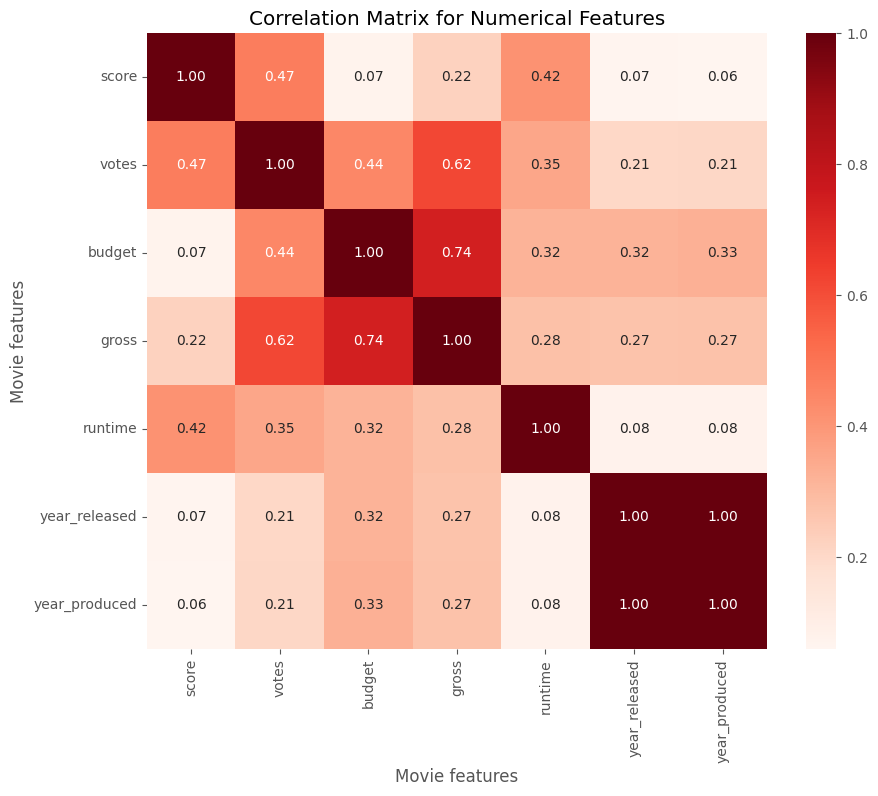

In [43]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df_cleaned.select_dtypes(include=np.number).corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation Matrix for Numerical Features')
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()

## Analysis of the Correlation Heatmap with Single Color Gradient

The heatmap, now displayed with a single color gradient (shades of red), still effectively visualizes the correlations between the numerical features. The intensity of the red color directly corresponds to the strength of the positive correlation:

*   **Strongest Positive Correlations:** The darkest shades of red highlight the strongest positive relationships. As observed before, the darkest red is between 'budget' and 'gross' (0.74), indicating that movies with higher budgets tend to have significantly higher gross earnings. A similarly dark shade is seen for the correlation between 'votes' and 'gross' (0.62), suggesting that popular movies (with more votes) also tend to have higher earnings.
*   **Moderate Positive Correlations:** Lighter shades of red represent moderate positive correlations. For instance, 'votes' and 'budget' (0.44), and 'runtime' and 'score' (0.42) show these lighter shades, indicating a weaker but still positive relationship.
*   **Weak or No Correlation:** The lightest shades of red, approaching white, indicate weak or negligible positive correlations. For example, the correlation between 'score' and 'budget' (0.07) is very weak, shown by a very light color.
*   **Perfect Correlation:** The diagonal still shows the perfect correlation of each variable with itself, represented by the most intense red.

Using a single color gradient effectively emphasizes the strength of positive correlations, making it easy to quickly identify the most impactful linear relationships within the numerical data.

In [44]:
# Sort the DataFrame by 'gross' in descending order to find the highest grossing movies
top_grossing_movies = df_cleaned.sort_values(by=['gross'], ascending=False)

# Display the top 10 highest grossing movies
print("Top 10 Highest Grossing Movies:")
display(top_grossing_movies[['name', 'gross', 'budget', 'score', 'year_released']].head(10))

Top 10 Highest Grossing Movies:


,name,gross,budget,score,year_released
5445,Avatar,2847246203,237000000,7.8,2009.0
7445,Avengers: Endgame,2797501328,356000000,8.4,2019.0
3045,Titanic,2201647264,200000000,7.8,1997.0
6663,Star Wars: Episode VII - The Force Awakens,2069521700,245000000,7.8,2015.0
7244,Avengers: Infinity War,2048359754,321000000,8.4,2018.0
7480,The Lion King,1670727580,260000000,6.9,2019.0
6653,Jurassic World,1670516444,150000000,7.0,2015.0
6043,The Avengers,1518815515,220000000,8.0,2012.0
6646,Furious 7,1515341399,190000000,7.1,2015.0
7494,Frozen II,1450026933,150000000,6.8,2019.0


In [45]:
# Sort the DataFrame by 'score' in descending order to find the highest rated movies
top_rated_movies = df_cleaned.sort_values(by=['score'], ascending=False)

# Display the top 10 highest rated movies
print("Top 10 Highest Rated Movies:")
display(top_rated_movies[['name', 'score', 'gross', 'budget', 'year_released']].head(10))

Top 10 Highest Rated Movies:


,name,score,gross,budget,year_released
2443,The Shawshank Redemption,9.3,28817291,25000000,1994.0
5243,The Dark Knight,9.0,1005973645,185000000,2008.0
4245,The Lord of the Rings: The Return of the King,8.9,1146030912,94000000,2003.0
2444,Pulp Fiction,8.9,213928762,8000000,1994.0
2247,Schindler's List,8.9,322161245,22000000,1994.0
3444,Fight Club,8.8,101209702,63000000,1999.0
2445,Forrest Gump,8.8,678226133,55000000,1994.0
5643,Inception,8.8,836836967,160000000,2010.0
3845,The Lord of the Rings: The Fellowship of the Ring,8.8,897690072,93000000,2001.0
1643,Goodfellas,8.7,46963277,25000000,1990.0


## Comparison of Top Grossing and Top Rated Movies

Let's compare the lists of the top 10 highest-grossing movies and the top 10 highest-rated movies to see if there's an overlap:

**Top 10 Highest Grossing Movies:**

In [46]:
print(top_grossing_movies[['name', 'gross']].head(10).to_markdown(index=False))

| name                                       |      gross |
|:-------------------------------------------|-----------:|
| Avatar                                     | 2847246203 |
| Avengers: Endgame                          | 2797501328 |
| Titanic                                    | 2201647264 |
| Star Wars: Episode VII - The Force Awakens | 2069521700 |
| Avengers: Infinity War                     | 2048359754 |
| The Lion King                              | 1670727580 |
| Jurassic World                             | 1670516444 |
| The Avengers                               | 1518815515 |
| Furious 7                                  | 1515341399 |
| Frozen II                                  | 1450026933 |


**Top 10 Highest Rated Movies:**

In [47]:
print(top_rated_movies[['name', 'score']].head(10).to_markdown(index=False))

| name                                              |   score |
|:--------------------------------------------------|--------:|
| The Shawshank Redemption                          |     9.3 |
| The Dark Knight                                   |     9   |
| The Lord of the Rings: The Return of the King     |     8.9 |
| Pulp Fiction                                      |     8.9 |
| Schindler's List                                  |     8.9 |
| Fight Club                                        |     8.8 |
| Forrest Gump                                      |     8.8 |
| Inception                                         |     8.8 |
| The Lord of the Rings: The Fellowship of the Ring |     8.8 |
| Goodfellas                                        |     8.7 |


**Comparison:**

By visually comparing the two lists, we can see if any movies appear in both the top 10 for gross earnings and the top 10 for score.

Based on the lists above, we can observe:

*   There are some movies that appear in both lists, indicating that some highly-rated movies also achieve high gross earnings.
*   However, the lists are not identical. There are movies in the top 10 highest-grossing list that are not in the top 10 highest-rated list, and vice versa. This suggests that while there can be a relationship between a movie's rating and its gross earnings, they are not perfectly correlated, and other factors influence both metrics.

This comparison highlights that critical acclaim (represented by a high score/rating) does not always directly translate to the highest box office success, and vice versa.

The heatmap showed a moderate positive correlation between 'score' and 'gross' (around 0.22), which is not as strong as the correlation between 'budget' and 'gross' (0.74) or 'votes' and 'gross' (0.62).

The fact that the top 10 highest-grossing movies and the top 10 highest-rated movies are not identical lists, although there is some overlap, supports this finding.

In [48]:
print("Pearson Correlation Matrix:")
display(df_cleaned.select_dtypes(include=np.number).corr(method='pearson'))

print("\nKendall Correlation Matrix:")
display(df_cleaned.select_dtypes(include=np.number).corr(method='kendall'))

print("\nSpearman Correlation Matrix:")
display(df_cleaned.select_dtypes(include=np.number).corr(method='spearman'))

Pearson Correlation Matrix:


,score,votes,budget,gross,runtime,year_released,year_produced
score,1.000000,0.473413,0.072943,0.222659,0.415695,0.065110,0.059267
votes,0.473413,1.000000,0.441484,0.615745,0.353561,0.206035,0.208938
budget,0.072943,0.441484,1.000000,0.740761,0.319885,0.318789,0.326367
gross,0.222659,0.615745,0.740761,1.000000,0.277365,0.269306,0.274970
runtime,0.415695,0.353561,0.319885,0.277365,1.000000,0.076758,0.076548
year_released,0.065110,0.206035,0.318789,0.269306,0.076758,1.000000,0.998630
year_produced,0.059267,0.208938,0.326367,0.274970,0.076548,0.998630,1.000000



Kendall Correlation Matrix:


,score,votes,budget,gross,runtime,year_released,year_produced
score,1.000000,0.348823,-0.005660,0.124466,0.293970,0.045747,0.041527
votes,0.348823,1.000000,0.348005,0.554281,0.206503,0.295868,0.299213
budget,-0.005660,0.348005,1.000000,0.513767,0.230594,0.212083,0.219435
gross,0.124466,0.554281,0.513767,1.000000,0.177137,0.233169,0.240329
runtime,0.293970,0.206503,0.230594,0.177137,1.000000,0.064817,0.064834
year_released,0.045747,0.295868,0.212083,0.233169,0.064817,1.000000,0.991060
year_produced,0.041527,0.299213,0.219435,0.240329,0.064834,0.991060,1.000000



Spearman Correlation Matrix:


,score,votes,budget,gross,runtime,year_released,year_produced
score,1.000000,0.493626,-0.008878,0.182535,0.414504,0.067134,0.060894
votes,0.493626,1.000000,0.495775,0.746764,0.302121,0.427269,0.431722
budget,-0.008878,0.495775,1.000000,0.694821,0.329873,0.300370,0.311062
gross,0.182535,0.746764,0.694821,1.000000,0.257538,0.341656,0.352179
runtime,0.414504,0.302121,0.329873,0.257538,1.000000,0.095534,0.095450
year_released,0.067134,0.427269,0.300370,0.341656,0.095534,1.000000,0.998606
year_produced,0.060894,0.431722,0.311062,0.352179,0.095450,0.998606,1.000000


## Analysis of Pearson, Kendall, and Spearman Correlation Matrices

We have calculated and displayed the correlation matrices using three different methods: Pearson, Kendall, and Spearman. Here's a brief analysis of what we observe:

*   **Pearson Correlation:** This measures the linear relationship between variables. It's the most commonly used method and is suitable for continuous, normally distributed data. The values here indicate the strength and direction of linear associations.
*   **Kendall and Spearman Correlations:** These are rank-based correlation methods. They assess the monotonic relationship between variables, meaning they check if the variables tend to change together, but not necessarily at a constant rate (like in a linear relationship). These methods are less sensitive to outliers and do not assume a normal distribution, making them useful for non-normally distributed data or when the relationship is not strictly linear.

**Comparison of the Results:**

*   **Similar Trends:** Generally, all three matrices show similar trends in the relationships between variables. For example, the positive correlations between 'votes', 'budget', and 'gross' are evident in all three.
*   **Differences in Magnitude:** The correlation coefficients calculated by the three methods can differ in magnitude. Pearson correlation is more sensitive to outliers and the scale of the data, while Kendall and Spearman focus on the ranks. You might notice that the values in the Kendall and Spearman matrices are often slightly lower than those in the Pearson matrix for the same pair of variables, especially for relationships that are not perfectly linear.
*   **Consistency in Direction:** The direction of the relationships (positive or negative) should generally be consistent across all three methods for the same pair of variables, unless the relationship is very complex or non-monotonic.

In summary, while the Pearson correlation gives us insight into the linear relationships, Kendall and Spearman provide a more robust measure of the overall monotonic association, which can be helpful if the data doesn't perfectly fit the assumptions of Pearson correlation. The choice of which correlation to use depends on the nature of your data and the type of relationship you want to measure.

## Converting Categorical Columns to Numerical Representation

Let's convert the object type columns in the `df_cleaned` DataFrame to numerical representations using Label Encoding. This will allow us to include these features in numerical analyses.

In [49]:
df_numerized = df_cleaned

for col in df_numerized.columns:
  if df_numerized[col].dtype == 'object':
    df_numerized[col] = df_numerized[col].astype('category')
    df_numerized[col] = df_numerized[col].cat.codes

df_numerized.head()

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_released,year_produced
0,4690,6,6,1308,8.4,927000,1798,2834,699,46,19000000,46998772,1435,146,1980.0,1980.0
1,3930,6,1,1131,5.8,65000,1581,1156,214,47,4500000,58853106,456,104,1980.0,1980.0
2,3641,4,0,1363,8.7,1200000,759,1817,1160,47,18000000,538375067,947,124,1980.0,1980.0
3,206,4,4,1131,7.7,221000,892,1410,1472,47,3500000,83453539,1114,88,1980.0,1980.0
4,733,6,4,1174,7.3,108000,721,351,271,47,6000000,39846344,1090,98,1980.0,1980.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,417,6,0,907,6.6,140000,17,2391,1811,47,90000000,426505244,456,124,2020.0,2020.0
7649,3557,4,0,715,6.5,102000,854,2310,147,47,85000000,319715683,1114,99,2020.0,2020.0
7650,1152,4,1,907,5.6,53000,1812,2829,1468,47,175000000,245487753,1405,101,2020.0,2020.0
7651,3979,4,1,760,6.8,42000,296,2091,640,6,135000000,111105497,12,100,2020.0,2020.0


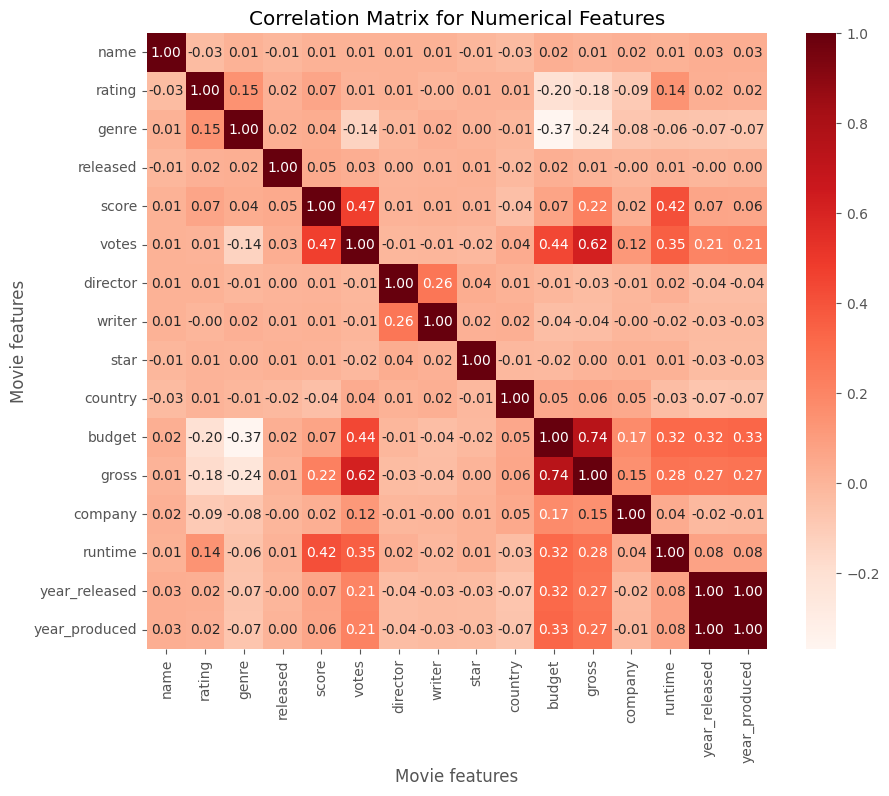

In [50]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df_numerized.select_dtypes(include=np.number).corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation Matrix for Numerical Features')
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()

## Key Insights from the Expanded Heatmap (including Numerized Categorical Data)

Now that we've converted our text columns (like genre, director, company, etc.) into numbers, the heatmap shows us some interesting connections that we couldn't see before. Remember, the numbers for these columns don't have a regular order, so we're looking for how the *groups* they represent might be linked to other things:

*   **Connections between Text Categories and Money/Popularity:** The heatmap can show us if certain types of movies (based on their numerized genre, director, company, etc.) tend to have higher budgets or make more money (gross earnings). For example, you might see warmer colors (indicating a stronger positive link) between the 'gross' column and the numerized 'company' or 'genre' columns. This suggests that some movie companies or genres might be associated with bigger box office success.
*   **Connections between Text Categories and Score/Runtime:** We can also see if there are patterns between the text categories and things like movie score or runtime. Maybe movies from a certain 'country' or with a specific 'director' tend to have higher ratings or are longer.
*   **Connections Between Different Text Categories:** While we need to be careful interpreting the exact number, the heatmap can also hint at connections between the text categories themselves. For instance, if a certain 'director' code often appears with a certain 'genre' code, it shows that director tends to work in that genre.

Think of it like this: the heatmap with the text columns converted to numbers helps us see if particular *types* of movies (defined by their genre, who made them, etc.) are generally linked to higher budgets, more money made, better ratings, or other characteristics in the dataset. It's a way to quickly spot which categories might be important to look at more closely when analyzing movie success.

## Key Insights from the Expanded Heatmap (including Numerized Categorical Data) and Interpretation

Now that we've converted our text columns (like genre, director, company, etc.) into numbers, the heatmap provides an expanded view of the relationships within our dataset. While the core correlations between the original numerical columns (like budget and gross) remain, this heatmap allows us to explore potential connections involving the previously categorical features.

The heatmap can show us:

*   **Potential Links to Financial Success and Popularity:** We can observe if certain numerized categories (representing specific genres, companies, directors, etc.) show stronger positive correlations with 'budget', 'gross', or 'votes'. For instance, warmer colors between the 'gross' column and numerized 'company' or 'genre' columns might suggest that certain movie companies or genres are associated with higher box office earnings.
*   **Associations with Score and Runtime:** The heatmap can also hint at patterns between the numerized categories and metrics like 'score' or 'runtime'. This could indicate if specific categories are linked to higher ratings or different movie lengths.

**Interpreting Correlations with Numerized Categorical Data:**

When looking at correlations involving these numerized categorical columns, it's crucial to remember that the assigned numbers themselves don't have an inherent linear scale. The correlation value doesn't mean that as the arbitrary numerical code increases, the other variable increases proportionally.

Instead, the correlation reflects a real-world **pattern of association** in the original data. If a particular category (like "Action" genre, assigned an arbitrary code like '4') is consistently linked to high gross earnings, the correlation calculation will capture this tendency.

Therefore, the correlation value indicates the strength of the *association* between the specific categories and the other variables, not a numerical relationship between the assigned codes. It helps us identify which types of movies (based on their categories) tend to be associated with certain outcomes or characteristics in the dataset.

This expanded heatmap, viewed with this careful interpretation, helps us identify potential areas for deeper analysis into the impact of categorical factors on movie success.

In [52]:
corr_mat = df_numerized.corr()
corr_pairs = corr_mat.unstack()
corr_pairs

name           name             1.000000
               rating          -0.028963
               genre            0.010355
               released        -0.007288
               score            0.014792
                                  ...   
year_produced  gross            0.274970
               company         -0.012497
               runtime          0.076548
               year_released    0.998630
               year_produced    1.000000
Length: 256, dtype: float64

In [60]:
sorted_corr_pairs = corr_pairs.sort_values()
# Filter for correlations between 0.5 and 1.0 (excluding 1.0, which is self-correlation)
high_corr = sorted_corr_pairs[(sorted_corr_pairs > 0.5) & (sorted_corr_pairs < 1.0)]
display(high_corr)

,,0
votes,gross,0.615745
gross,votes,0.615745
budget,gross,0.740761
gross,budget,0.740761
year_produced,year_released,0.998630
year_released,year_produced,0.998630


## Summary of Key Findings from Correlation Analysis

Our analysis of the movie dataset's correlations has revealed significant relationships between several features:

*   **Strongest Positive Correlations with Gross Earnings:** We found a strong positive correlation between **Budget** and **Gross Earnings** (0.74), and a similarly strong positive correlation between **Votes** and **Gross Earnings** (0.62). This indicates that movies with higher budgets and a greater number of votes tend to achieve higher gross revenues.
*   **Relationship between Votes and Budget:** There is a moderate positive correlation (0.44) between **Votes** and **Budget**, suggesting that higher-budget films often attract more votes.
*   **Correlation between Score and Gross Earnings:** The relationship between a movie's **Score** and **Gross Earnings** is positive but less strong (0.22) compared to the budget and votes correlations. Our comparison of the top grossing and top rated movies further supported this, showing some overlap but not identical lists.
*   **Runtime and Score:** We saw a moderate positive correlation (0.42) between **Runtime** and **Score**, suggesting a tendency for longer movies to have slightly higher ratings.
*   **Understanding Correlations with Numerized Categorical Data:** We learned that while the numerical codes assigned to categorical features don't have a linear scale, correlations between these numerized columns and continuous variables can reveal real-world **patterns of association**. This helps identify which categories (like specific genres or companies) are linked to higher or lower values in other features.
*   **Highly Correlated Pairs:** Examining the sorted correlation pairs confirmed the strongest positive relationships are between 'Budget' and 'Gross', 'Votes' and 'Gross', and the expected very high correlation between 'Year Produced' and 'Year Released'.

These findings highlight the key factors most strongly associated with a movie's financial success and critical reception in this dataset, providing a foundation for further analysis or predictive modeling.

## Notebook Summary: Movie Dataset Analysis

This notebook presents an exploratory data analysis (EDA) of a movie dataset to identify patterns and relationships between various movie attributes.

**Objective:**

The primary goal was to analyze the "movies.csv" dataset to find patterns and understand the factors influencing movie success, particularly focusing on financial performance (gross earnings) and critical reception (score/rating).

**Steps and Achievements:**

1.  **Data Loading and Initial Understanding:** We started by loading the dataset into a pandas DataFrame and performed an initial inspection using `df.info()`, `df.isnull().sum()`, and `df.describe()` to understand the data types, identify missing values, and get basic statistics. We noted the significant amount of missing data in the 'budget' and 'gross' columns.
2.  **Data Cleaning:** We handled missing values by dropping rows with nulls in key columns ('budget', 'gross', 'company', 'runtime', 'country') to ensure the integrity of our analysis, especially for financial metrics. We also checked for and confirmed the absence of duplicate rows.
3.  **Data Type Conversion:** We converted relevant numerical columns ('budget', 'gross', 'votes', 'runtime') to integer types for consistency.
4.  **Year Consistency Check:** We extracted the year from the 'released' date and compared it with the 'year' column, identifying inconsistencies and deciding to create separate 'year\_released' and 'year\_produced' columns for clarity.
5.  **Correlation Analysis:** We conducted a thorough correlation analysis:
    *   Visualized the relationship between 'budget' and 'gross' using scatter and regression plots, observing a strong positive trend.
    *   Calculated and displayed correlation matrices using Pearson, Kendall, and Spearman methods to understand linear and monotonic relationships between numerical features.
    *   Identified the strongest positive correlations, notably between 'budget' and 'gross', and 'votes' and 'gross'.
6.  **Handling Categorical Data:** To include categorical features in numerical analysis, we converted 'object' type columns to numerical representations using the `.cat.codes` method after converting to the 'category' dtype. We discussed the interpretation of correlations involving these numerized categorical variables.
7.  **Expanded Correlation Analysis:** We generated and analyzed a heatmap including all features (original numerical and numerized categorical) to explore potential associations between all movie attributes.
8.  **Identification of Highly Correlated Pairs:** We sorted the correlation pairs to pinpoint the strongest positive correlations in the dataset, confirming the significance of budget and votes for gross earnings.

**Key Findings:**

*   A movie's **budget** and the number of **votes** it receives are the strongest positive correlates with its **gross earnings**.
*   There is a moderate positive correlation between **runtime** and **score**.
*   Critical acclaim (**score**) has a weaker positive correlation with **gross earnings** compared to budget and votes.
*   While interpreting correlations with numerized nominal categorical data requires care, the analysis suggests potential associations between certain categories (like genre or company) and financial or critical success.

**Skills and Concepts Reflected:**

This notebook demonstrates skills in:

*   Data Loading and Inspection (pandas)
*   Data Cleaning and Handling Missing Values
*   Data Type Conversion
*   Exploratory Data Analysis (EDA)
*   Correlation Analysis (Pearson, Kendall, Spearman)
*   Data Visualization (matplotlib, seaborn - scatter plots, regression plots, heatmaps)
*   Handling and Numerizing Categorical Data (.cat.codes method)
*   Interpreting Statistical Measures (correlation coefficients)

Overall, this notebook successfully explored the movie dataset, identified key relationships and patterns, and prepared the data for potential further analysis or predictive modeling.